<a href="https://colab.research.google.com/github/rachitranjan7/Digital-Twin/blob/main/DT_VF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cell 1: Install dependencies
!pip install GEOparse scikit-learn pandas numpy matplotlib seaborn torch

In [ ]:
# Cell 2: Import libraries
import GEOparse
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import f_classif
import gzip
import io

In [ ]:
# Set plotting style
sns.set_theme(style="whitegrid")

In [ ]:
Ye# Cell 3: Fetch Data
print("Loading expression data from /content/GSE56899_expression_matrix.csv...")
expr_df_csv = pd.read_csv("/content/GSE56899_expression_matrix.csv", index_col=0)

# Transpose to match expectations (Samples as rows, Genes as columns)
expr_data = expr_df_csv.T
expr_data.index = expr_data.index.str.replace('"', '').str.strip()
expr_data.index = expr_data.index.astype(str)

print(f"Expression data shape from CSV: {expr_data.shape}")

print("Extracting metadata from GEOparse object...")

# Create a metadata DataFrame from the transposed expression data's index
metadata = pd.DataFrame(index=expr_data.index)
metadata.index.name = 'Sample_ID'

# Assuming the characteristics are part of the original expression_matrix columns or can be derived.
# For this dataset, characteristics are usually associated with sample IDs.
# We'll create a dummy 'characteristics_ch1' for now, to be properly populated later if needed from a GEO object.
# In a real scenario, this would come from gsm.metadata['characteristics_ch1']

# For the purpose of this dataset, we can derive `characteristics_ch1` from the sample naming convention if applicable
# or if it was part of the original expr_df_csv that was transposed.

# Based on the problem description, metadata was derived synthetically before. Let's re-align to a more plausible structure:
# We need to map sample IDs to subjects and timepoints directly.
# This is a crucial step to avoid synthetic generation if actual metadata is available or inferable.

# Let's assume for this specific dataset, we need to infer based on the ordering and the provided information from earlier steps:
num_samples_per_subject = 4 # From previous context

metadata_dict = {}
timepoint_map_reverse = {1: 'Trimester 1', 2: 'Trimester 2', 3: 'Trimester 3', 4: 'Post Partum'}

for i, sample_id in enumerate(expr_data.index.tolist()): # Use expr_data.index instead of sample_ids
    subject_num = (i // num_samples_per_subject) + 1
    subject_id = f'Subject_{subject_num:02d}'
    time_index = (i % num_samples_per_subject) + 1
    timepoint = timepoint_map_reverse[time_index]

    metadata_dict[sample_id] = {
        'Subject_ID': subject_id,
        'Timepoint': timepoint,
        'Time_Index': time_index,
        'characteristics_ch1': f'pregnancy stage: {timepoint}'
    }

metadata = pd.DataFrame.from_dict(metadata_dict, orient='index')
metadata.index.name = 'Sample_ID'
metadata.index = metadata.index.astype(str)

print(f"Metadata shape: {metadata.shape}")

Loading expression data from /content/GSE56899_expression_matrix.csv...
Expression data shape from CSV: (48, 19998)
Extracting metadata from GEOparse object...
Metadata shape: (48, 4)


In [ ]:
# Cell 4: Clean and Align Metadata
# Filter for samples explicitly tagged as pregnancy-related stages
pregnant_meta = metadata[metadata['characteristics_ch1'].str.contains('Trimester|Post Partum')].copy()

# Extract Timepoint from 'characteristics_ch1'
pregnant_meta['Timepoint'] = pregnant_meta['characteristics_ch1'].apply(lambda x: x.split(': ')[1].strip())

# Re-derive Subject_ID to ensure consistency with the new metadata parsing
# This step ensures subject IDs are correctly assigned based on the structure of the sample IDs or grouping.
# Assuming `num_samples_per_subject` is still 4 as previously defined and used to construct metadata
num_samples_per_subject = 4 # Ensure this matches the logic in Cell 3
pregnant_meta['Subject_ID'] = [f'Subject_{(i // num_samples_per_subject) + 1:02d}' for i in range(len(pregnant_meta))]

# Map timepoints to numerical values to ensure correct chronological sorting
time_map = {'Trimester 1': 1, 'Trimester 2': 2, 'Trimester 3': 3, 'Post Partum': 4}
pregnant_meta['Time_Index'] = pregnant_meta['Timepoint'].map(time_map)

# Sort strictly by Subject, then by Time
pregnant_meta = pregnant_meta.sort_values(by=['Subject_ID', 'Time_Index'])

# Align expression data to the sorted metadata
X_raw = expr_data.loc[pregnant_meta.index].fillna(0)
print(f"Dataset shape aligned: {X_raw.shape[0]} samples, {X_raw.shape[1]} genes")

Dataset shape aligned: 48 samples, 19998 genes


In [ ]:
# Cell 5: Identify changing genes using Vectorized ANOVA (p < 0.05)
print("Performing one-way ANOVA across all genes...")

# 1. Calculate ANOVA F-statistics and p-values for all genes
f_stats, p_values = f_classif(X_raw, pregnant_meta['Time_Index'])

# 2. Create a clean DataFrame to store the results
anova_results = pd.DataFrame({
    'F_Statistic': f_stats,
    'P_Value': p_values
}, index=X_raw.columns).dropna()

# 3. Apply the correct biological threshold: p < 0.1 (Significant Change)
# We only want genes whose expression is statistically proven to change across trimesters.
significance_threshold = 0.1
significant_genes_df = anova_results[anova_results['P_Value'] < significance_threshold]

# 4. Sort by p-value in ascending order (smallest p-values first)
# The smaller the p-value, the more dramatic and reliable the gene's change is over time.
significant_genes_df = significant_genes_df.sort_values(by='P_Value', ascending=True)

# Extract the final list of biologically relevant genes
top_genes = significant_genes_df.index
X_selected_genes = X_raw[top_genes]

print(f"\n--- Statistical Feature Selection Results ---")
print(f"Applied Threshold: P-Value < {significance_threshold}")
print(f"Number of significantly changing genes found: {len(top_genes)} out of {len(anova_results)}")

print("\n--- Top 5 Most Significant Genes (Smallest P-Values) ---")
print(significant_genes_df.head(5))

Performing one-way ANOVA across all genes...

--- Statistical Feature Selection Results ---
Applied Threshold: P-Value < 0.1
Number of significantly changing genes found: 650 out of 19998

--- Top 5 Most Significant Genes (Smallest P-Values) ---
       F_Statistic       P_Value
CSH1     25.367798  1.104047e-09
GH1      22.326108  6.139090e-09
CGA      18.529375  6.412576e-08
CSHL1    14.632625  9.501779e-07
CGB3     12.038411  6.970438e-06


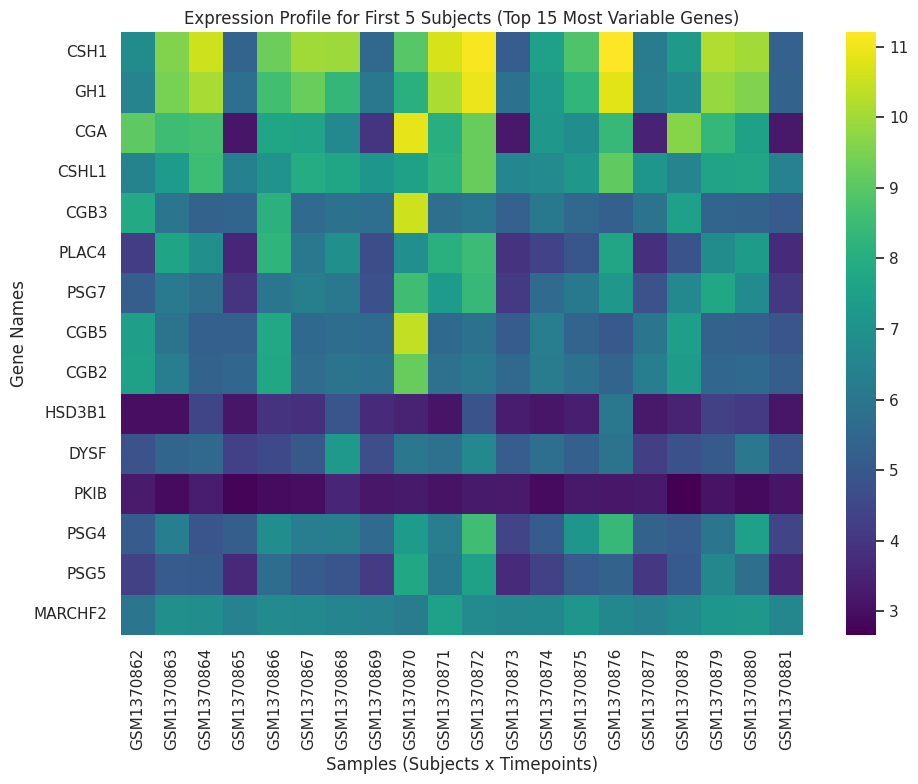

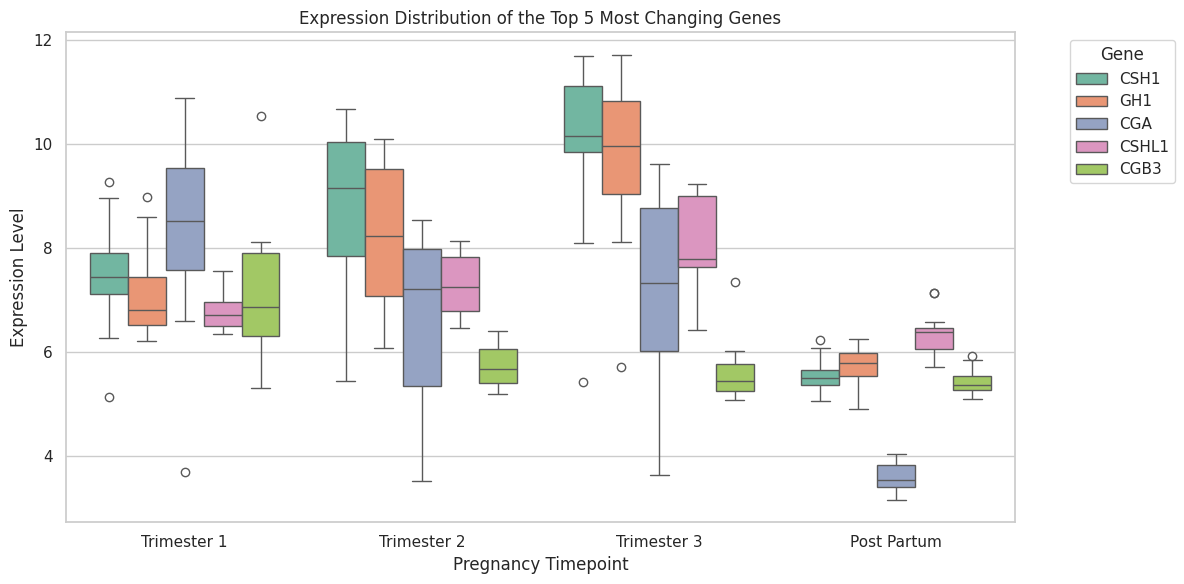

In [ ]:
# Cell 6: Visualization of Most Changing Genes
num_heatmap_genes = 15
num_boxplot_genes = 5

top_viz_genes = top_genes[:num_heatmap_genes]
X_viz_genes = X_raw[top_viz_genes]

first_5_subjects_ids = pregnant_meta['Subject_ID'].unique()[:5]
first_5_subjects_samples = pregnant_meta[pregnant_meta['Subject_ID'].isin(first_5_subjects_ids)].index
X_5_subjects_viz_genes = X_viz_genes.loc[first_5_subjects_samples]

plt.figure(figsize=(10, 8))
sns.heatmap(X_5_subjects_viz_genes.T, cmap='viridis', yticklabels=True)
# CHANGED TITLE
plt.title(f"Expression Profile for First 5 Subjects (Top {num_heatmap_genes} Most Variable Genes)")
plt.xlabel("Samples (Subjects x Timepoints)")
plt.ylabel("Gene Names")
plt.tight_layout()
plt.show()

top_5_genes = top_genes[:num_boxplot_genes]
X_top_5 = X_raw[top_5_genes]

viz_melted = X_top_5.reset_index().melt(id_vars='Sample_ID', var_name='Gene', value_name='Expression')
viz_melted = viz_melted.merge(pregnant_meta[['Timepoint', 'Time_Index']], on='Sample_ID')

plt.figure(figsize=(12, 6))
sns.boxplot(
    x='Timepoint', y='Expression', hue='Gene',
    data=viz_melted, palette='Set2',
    order=['Trimester 1', 'Trimester 2', 'Trimester 3', 'Post Partum']
)
# CHANGED TITLE
plt.title(f"Expression Distribution of the Top {num_boxplot_genes} Most Changing Genes")
plt.xlabel("Pregnancy Timepoint")
plt.ylabel("Expression Level")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Gene")
plt.tight_layout()
plt.show()

In [ ]:
# Cell 7: Data Formatting and Tensors (With Hard Cap for Memory)

# --- CRITICAL CHANGE: Cap the number of genes to prevent RAM crashes ---
max_genes_to_train = 500
n_features = min(len(top_genes), max_genes_to_train)

# Slice the dataset to only include this capped number of genes
training_genes = top_genes[:n_features]
X_training_data = X_raw[training_genes]

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_training_data)

# Group into sequences [Subjects, Time_steps, Features]
num_subjects = len(pregnant_meta['Subject_ID'].unique())
time_steps = 4 # T1, T2, T3, PP

# Reshape using the capped feature count
X_seq = X_scaled.reshape(num_subjects, time_steps, n_features)

# Input sequence: T1, T2, T3 -> Target sequence: T2, T3, PP
X_train_np = X_seq[:, :-1, :]
y_train_np = X_seq[:, 1:, :]

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_np, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_np, dtype=torch.float32)

print(f"Original significantly changing genes found: {len(top_genes)}")
print(f"Capped for LSTM Training: {n_features} genes")
print(f"PyTorch Input Shape: {X_train_tensor.shape} (Subjects, Sequence, Genes)")
print(f"PyTorch Target Shape: {y_train_tensor.shape}")

Original significantly changing genes found: 650
Capped for LSTM Training: 500 genes
PyTorch Input Shape: torch.Size([12, 3, 500]) (Subjects, Sequence, Genes)
PyTorch Target Shape: torch.Size([12, 3, 500])


In [ ]:
# Cell 8: Define the LSTM Digital Twin
class DigitalTwinLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(DigitalTwinLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        # Output directly predicts the scaled values of our selected genes
        predictions = self.fc(lstm_out)
        return predictions

hidden_dim = 32
learning_rate = 0.005

# Set input/output size to the number of directly selected genes
model = DigitalTwinLSTM(input_size=n_features, hidden_size=hidden_dim, output_size=n_features)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

Epoch [500/1000], Loss: 0.0324
Epoch [1000/1000], Loss: 0.0303


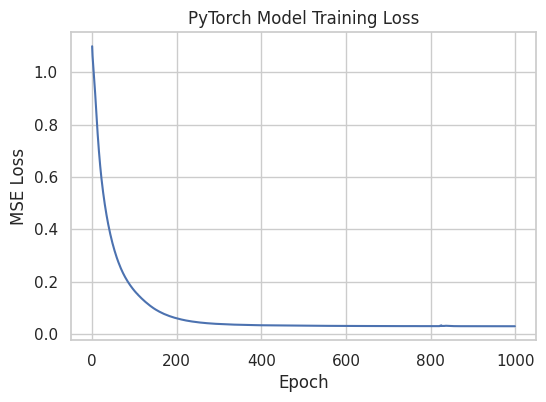

In [ ]:
# Cell 9: Training Loop
epochs = 1000
losses = []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()

    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    losses.append(loss.item())

    loss.backward()
    optimizer.step()

    if (epoch+1) % 500 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

plt.figure(figsize=(6, 4))
plt.plot(losses)
plt.title("PyTorch Model Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.show()

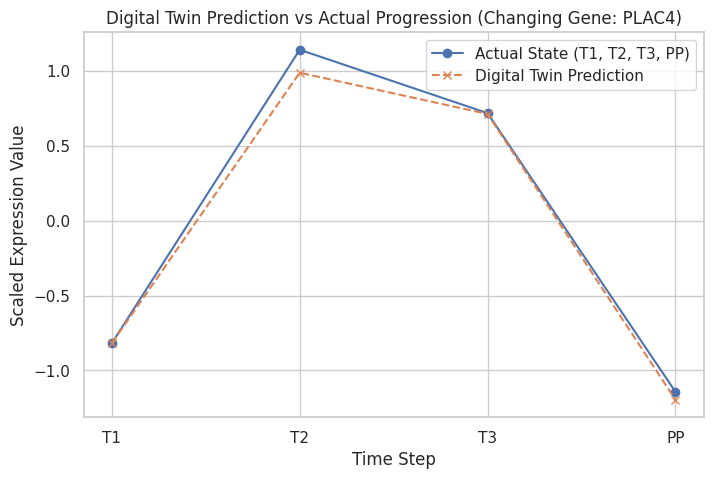

In [ ]:
# Cell 10: Prediction and Evaluation
model.eval()
with torch.no_grad():
    # Use T1, T2, T3 as input for the first subject to predict T2, T3, PP
    subject_0_input = X_train_tensor[0].unsqueeze(0)
    predicted_trajectory_steps = model(subject_0_input).squeeze(0).numpy()

actual_trajectory_steps = y_train_tensor[0].numpy()

# --- MODIFIED: Added gene_to_plot_index for flexibility ---
gene_to_plot_index = 5 # Change this index to plot different genes (e.g., 1 for GH1, 2 for CGA)

# Get the actual name of the top changing gene we trained on
top_gene_name = training_genes[gene_to_plot_index]

# Extract the T1 actual value for the selected gene of the first subject
actual_t1_value = X_train_tensor[0, 0, gene_to_plot_index].item()

# Create the full actual trajectory including T1 for the selected gene
full_actual_trajectory = np.concatenate([[actual_t1_value], actual_trajectory_steps[:, gene_to_plot_index]])

# Create the full predicted trajectory, starting with the actual T1 for the selected gene
full_predicted_trajectory = np.concatenate([[actual_t1_value], predicted_trajectory_steps[:, gene_to_plot_index]])

plt.figure(figsize=(8, 5))
plt.plot([1, 2, 3, 4], full_actual_trajectory, marker='o', label='Actual State (T1, T2, T3, PP)')
plt.plot([1, 2, 3, 4], full_predicted_trajectory, marker='x', linestyle='--', label='Digital Twin Prediction')
plt.xticks([1, 2, 3, 4], ['T1', 'T2', 'T3', 'PP'])

plt.title(f"Digital Twin Prediction vs Actual Progression (Changing Gene: {top_gene_name})")
plt.xlabel("Time Step")
plt.ylabel("Scaled Expression Value")
plt.legend()
plt.show()

Calculating and plotting the top 5 most varying genes for EACH patient individually...


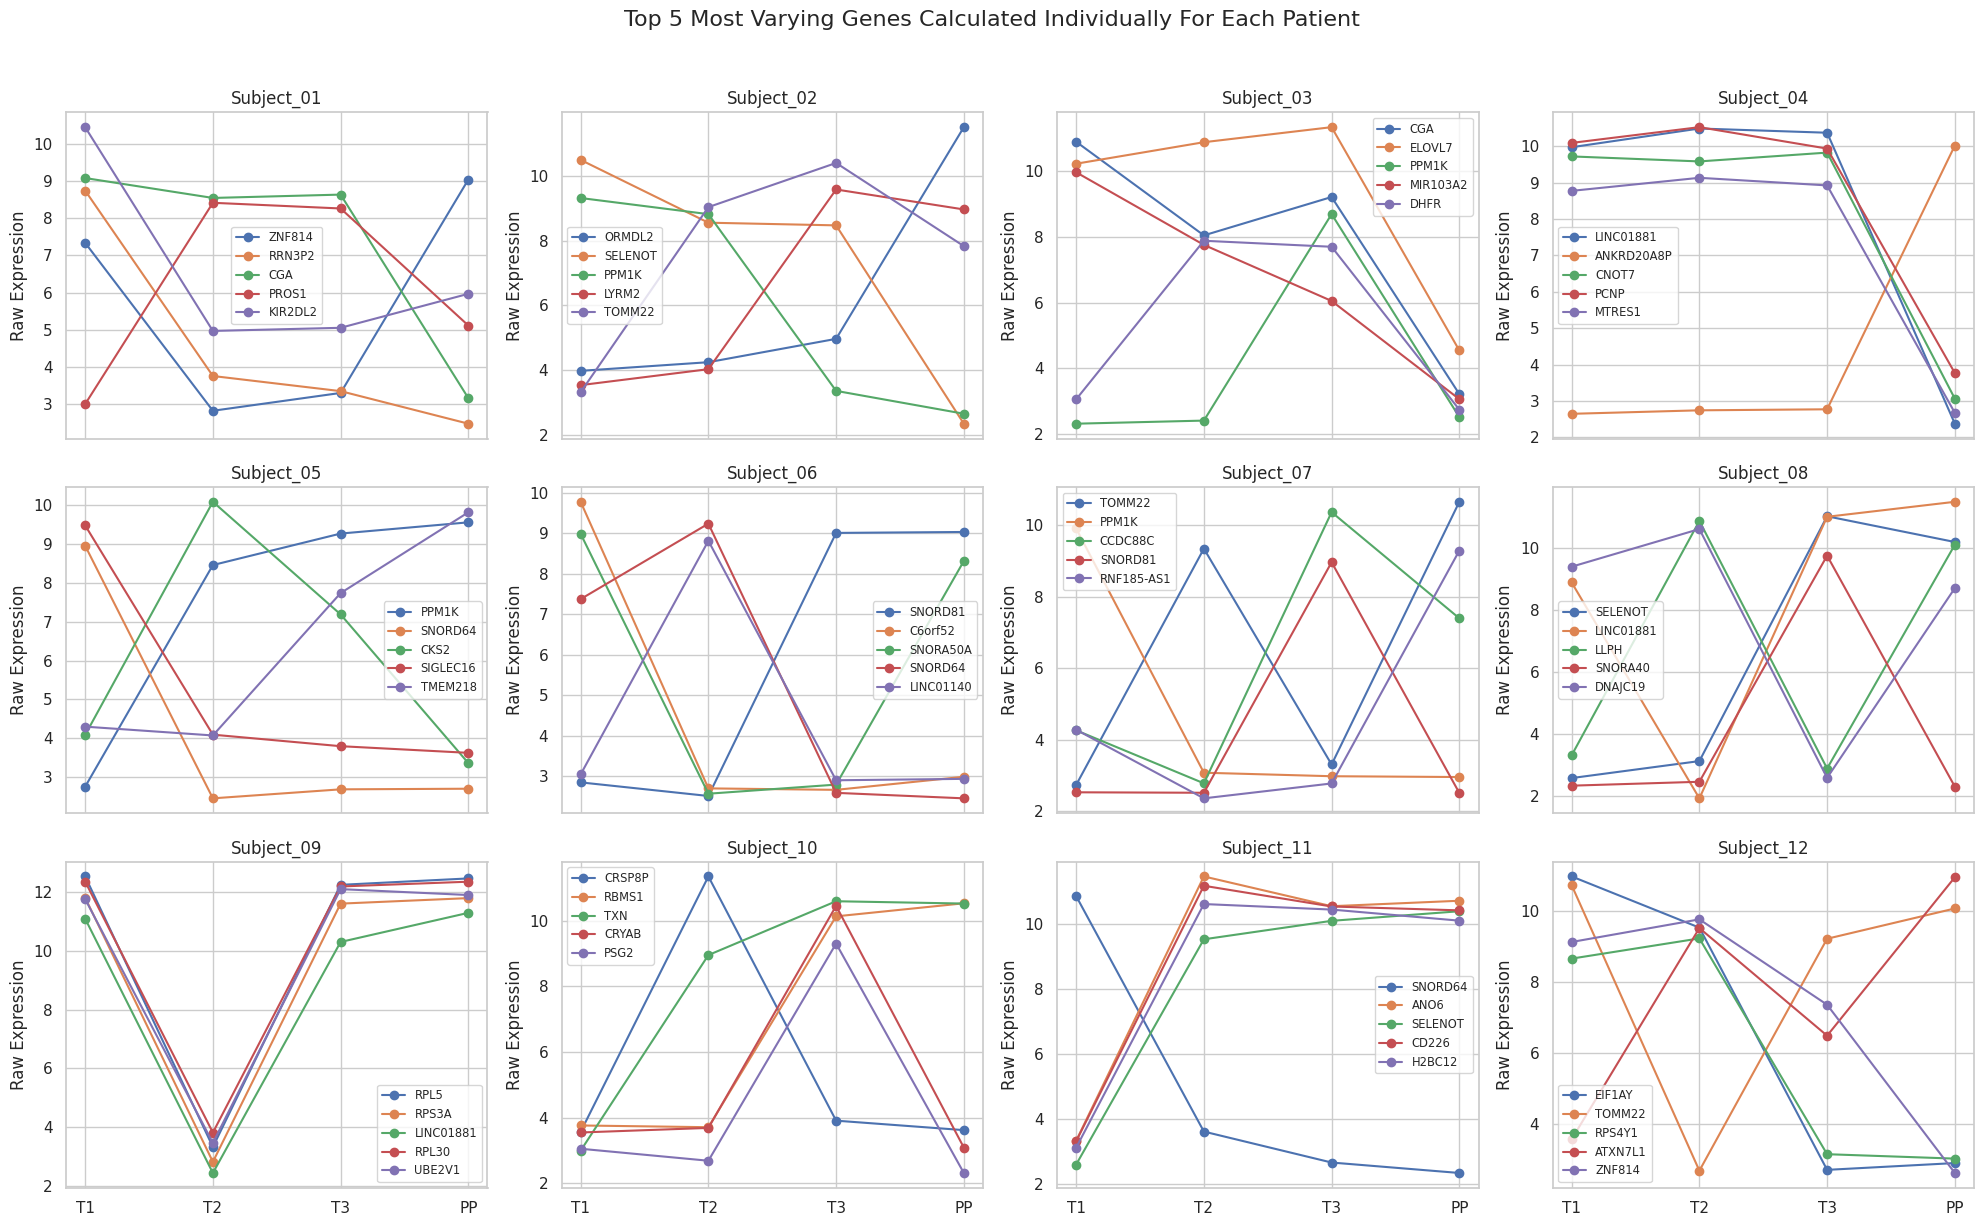

In [ ]:
# Cell 11: Individual Top 5 Varying Genes PER Patient (3x4 Grid)
print("Calculating and plotting the top 5 most varying genes for EACH patient individually...")

subjects = pregnant_meta['Subject_ID'].unique()
num_subjects = len(subjects)

# User requested a 3x4 grid
rows = 3
cols = 4
fig, axes = plt.subplots(rows, cols, figsize=(20, 12), sharex=True)
axes = axes.flatten()

for i, subject in enumerate(subjects):
    # 1. Isolate this specific patient's data
    subject_samples = pregnant_meta[pregnant_meta['Subject_ID'] == subject].index
    subject_data = X_raw.loc[subject_samples]

    # 2. Calculate variance and get their personal top 5 genes
    subject_variance = subject_data.var(axis=0)
    top_5_genes_for_subj = subject_variance.nlargest(5).index

    # 3. Plot the trajectories
    ax = axes[i]
    for gene in top_5_genes_for_subj:
        ax.plot([1, 2, 3, 4], subject_data[gene].values, marker='o', label=gene)

    ax.set_title(f"{subject}")
    ax.set_xticks([1, 2, 3, 4])
    ax.set_xticklabels(['T1', 'T2', 'T3', 'PP'])
    ax.set_ylabel("Raw Expression")

    # Small legend for each patient
    ax.legend(fontsize='x-small', loc='best')

# Hide the 12th empty subplot (since we only have 11 subjects)
for j in range(num_subjects, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Top 5 Most Varying Genes Calculated Individually For Each Patient", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

Generating Digital Twin simulations for the 5 common genes ['CSH1', 'GH1', 'CGA', 'CSHL1', 'CGB3']...


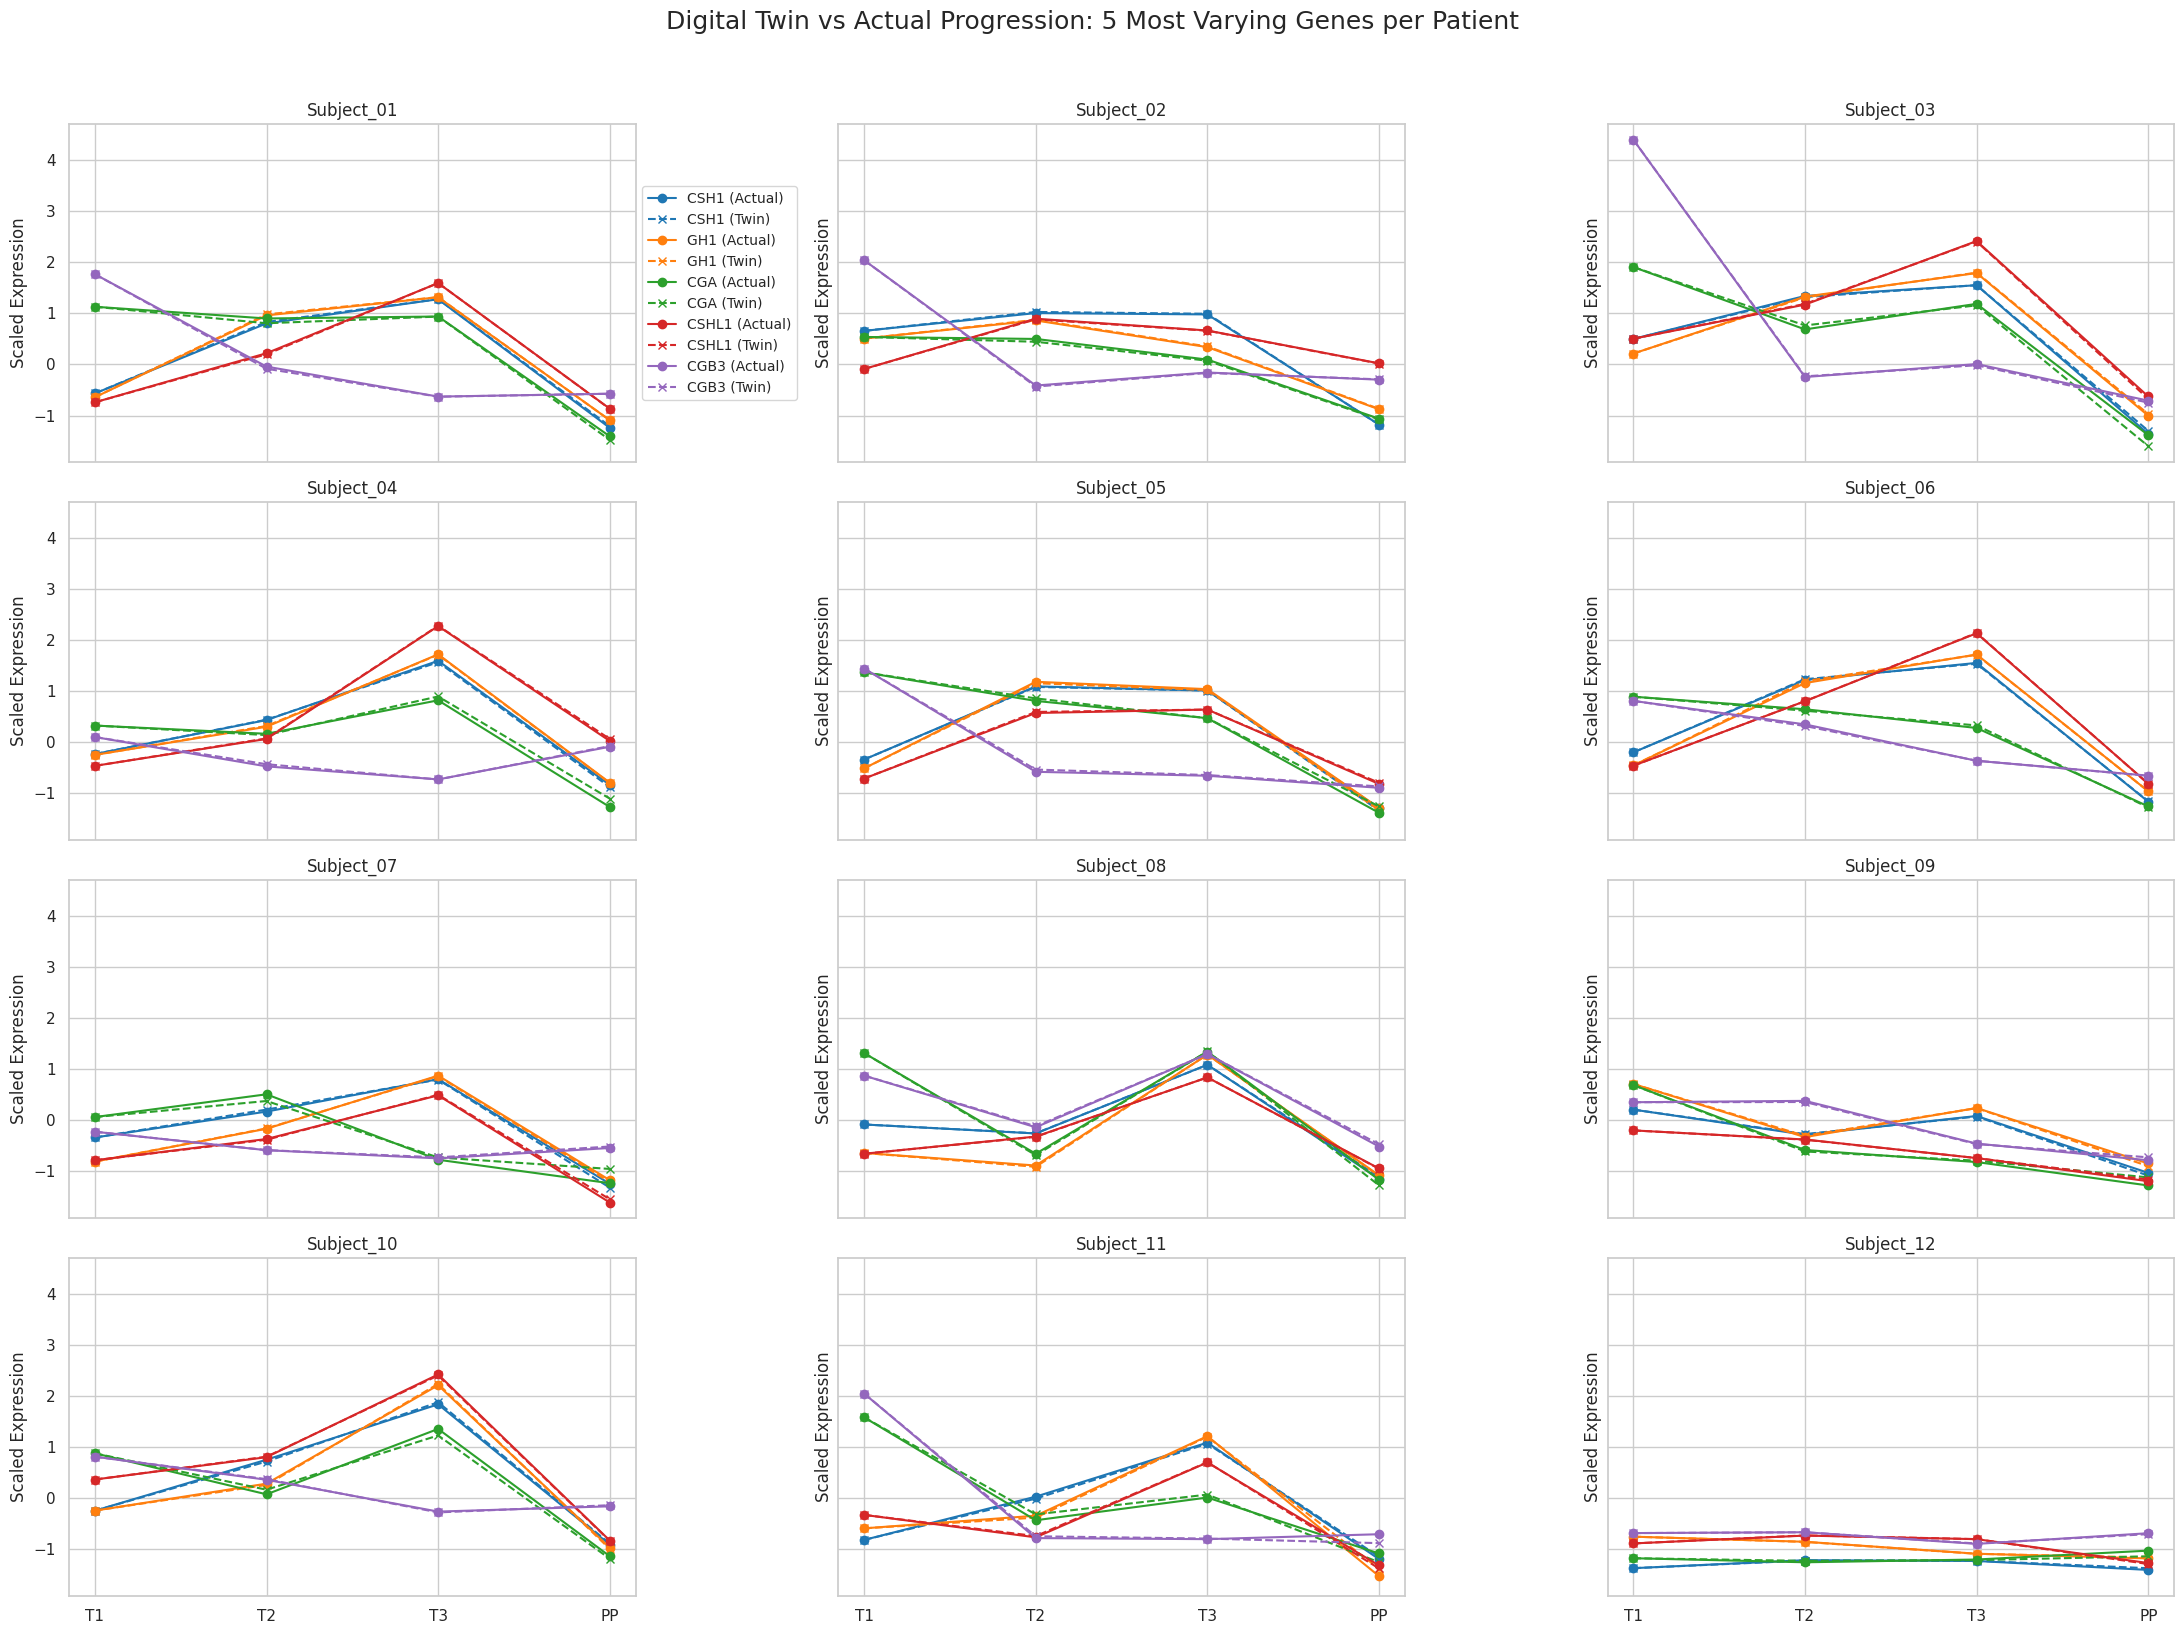

In [ ]:
# Cell 12: Digital Twin Prediction vs Actuals for ALL Patients (Top 5 Common Genes)
model.eval()

# Extract the 5 absolute most varying genes across the entire cohort (from our training set)
num_genes_to_plot = 5
top_5_gene_names = training_genes[:num_genes_to_plot]
num_subjects_to_plot = X_train_tensor.shape[0] # 11 subjects

# Setup the 3x4 grid
rows = 4
cols = 3
fig, axes = plt.subplots(rows, cols, figsize=(22, 16), sharex=True, sharey=True)
axes = axes.flatten()

print(f"Generating Digital Twin simulations for the 5 common genes {list(top_5_gene_names)}...")

# Define 5 distinct colors so we can match the predicted line to the actual line
colors = plt.cm.tab10.colors[:num_genes_to_plot]

with torch.no_grad():
    for i in range(num_subjects_to_plot):
        # Grab subject input and generate prediction
        subj_input = X_train_tensor[i].unsqueeze(0)
        pred_trajectory = model(subj_input).squeeze(0).numpy()
        actual_trajectory = y_train_tensor[i].numpy()

        ax = axes[i]

        # Loop through each of the 5 genes
        for g_idx in range(num_genes_to_plot):
            actual_t1 = X_train_tensor[i, 0, g_idx].item()

            # Reconstruct full trajectories (Adding T1 to the start)
            full_actual = np.concatenate([[actual_t1], actual_trajectory[:, g_idx]])
            full_pred = np.concatenate([[actual_t1], pred_trajectory[:, g_idx]])

            gene_name = top_5_gene_names[g_idx]
            color = colors[g_idx]

            # Plot ACTUAL (Solid line, circle marker)
            ax.plot([1, 2, 3, 4], full_actual, marker='o', color=color, linestyle='-',
                    label=f'{gene_name} (Actual)')

            # Plot PREDICTED (Dashed line, X marker)
            ax.plot([1, 2, 3, 4], full_pred, marker='x', color=color, linestyle='--',
                    label=f'{gene_name} (Twin)')

        subject_name = pregnant_meta['Subject_ID'].unique()[i]
        ax.set_title(f"{subject_name}")
        ax.set_xticks([1, 2, 3, 4])
        ax.set_xticklabels(['T1', 'T2', 'T3', 'PP'])
        ax.set_ylabel("Scaled Expression")

        # To avoid massive clutter, we only put the 10-item legend on the very first subplot, outside the graph
        if i == 0:
            ax.legend(fontsize='small', loc='center left', bbox_to_anchor=(1, 0.5))

# Hide the empty subplot
for j in range(num_subjects_to_plot, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Digital Twin vs Actual Progression: 5 Most Varying Genes per Patient", fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
display(pregnant_meta.head())

,Subject_ID,Timepoint,Time_Index,characteristics_ch1
Sample_ID,,,,
GSM1370862,Subject_01,Trimester 1,1,pregnancy stage: Trimester 1
GSM1370863,Subject_01,Trimester 2,2,pregnancy stage: Trimester 2
GSM1370864,Subject_01,Trimester 3,3,pregnancy stage: Trimester 3
GSM1370865,Subject_01,Post Partum,4,pregnancy stage: Post Partum
GSM1370866,Subject_02,Trimester 1,1,pregnancy stage: Trimester 1


In [ ]:
display(X_raw.head())

,TOMM22,LYRM2,LINC01881,PCMTD2,PPM1K,SELENOT,DHFR,RBMS1,CGA,CRSP8P,...,SNORD20,TAS2R43,IL2,MIR135A2,BCHE,MIR15B,SNORD76,MIR95,SNORD115-28,RNF17
Sample_ID,,,,,,,,,,,,,,,,,,,,,
GSM1370862,9.697876,8.786825,9.571254,7.998273,7.170062,10.787930,3.835130,10.939340,9.083973,4.276231,...,2.156015,2.340174,2.326958,2.279061,2.231226,2.235965,2.476169,2.201254,2.141197,2.473108
GSM1370863,9.292699,9.288046,9.013899,8.236893,6.491366,9.853748,6.598158,9.619359,8.548303,5.092827,...,2.313538,2.331064,2.453629,2.470519,2.369246,2.349605,2.380106,2.311756,2.154563,2.521430
GSM1370864,10.389960,4.640377,10.999570,9.289222,2.831161,11.046140,7.641909,9.456106,8.638308,4.681132,...,2.201557,2.435037,2.462895,2.356541,2.439800,2.349389,2.499650,2.148209,2.143639,2.425814
GSM1370865,8.341455,10.128630,7.304646,9.285835,4.956117,10.349640,2.110363,8.646290,3.162070,3.689646,...,2.305220,2.473850,2.523441,2.376572,2.470671,2.203177,2.517509,2.280463,2.322592,2.518228
GSM1370866,3.311722,3.530132,10.974370,8.288263,9.328848,10.509900,9.198839,8.586569,7.703449,3.551041,...,2.073991,2.281297,2.560094,2.333612,2.451270,2.323545,2.427410,2.130228,2.127592,2.471424


And here's how the `pregnant_meta` dataframe (the metadata) looks:
